# The descriptor and the training schedule: the eight arms that price them

Two knobs sit between the campaign's arms, and they are easy to confuse because both change
almost everything at once: **which descriptor** the model builds its representation from, and
**which training schedule** anneals the learning rate and reweights the energy term.
The eight arms below hold each knob still in turn, so the price of each one is read off a
single comparison instead of guessed from a cross-code factor.

They are the necessary arms because each knob needs its own control, and the long-range term
has to be priced separately inside every cell - a term whose worth depends on the other knob is
exactly what one ablation would hide.

## The necessary arms

| # | arm, as asked for | descriptor | schedule | code | topology | data arms |
|---|---|---|---|---|---|---|
| 1 | `cace` | cace's own | cace's | cace | SR only | `cace-sr` |
| 2 | `cace-lr` | cace's own | cace's | cace | SR + Ewald q | `cace-lr` |
| 3 | `cace(se_a)` | `se_a` | cace's | cace | SR only | `cace-sea-sr` |
| 4 | `cace(se_a)-lr` | `se_a` | cace's | cace | SR + Ewald q | `cace-sea-lr` |
| 5 | `deepmd(cace setting)` | `se_a` | cace's | deepmd | SR only | `deepmd-cace-sched_sA`, `_sB` |
| 6 | `deepmd(cace setting)-les` | `se_a` | cace's | deepmd | SR + Ewald q | `deepmd-les-cace-sched_sA`, `_sB` |
| 7 | `deepmd` | `se_a` | deepmd's | deepmd | SR only | `deepmd_sA`, `_sB` |
| 8 | `deepmd-lr` | `se_a` | deepmd's | deepmd | SR + Ewald q | `deepmd-les_sA`, `_sB` |

Every arm ends at the same amount of work: 80,000 steps, which is 500 epochs at 160 steps per
epoch (batch 2 over 320 training frames). cace counts epochs and deepmd counts steps, and the
two land on the same checkpoint, so one final checkpoint per arm is one number per arm and no
window has to be chosen.

## The controlled comparisons

Each row of FIG 2 moves exactly one knob, so the difference is attributable:

- **the descriptor**, at cace's schedule and in cace's loop: `cace` -> `cace(se_a)`, and again with the long-range term on;
- **the schedule**, at `se_a` and in deepmd's loop: `deepmd(cace setting)` -> `deepmd`, and again with the long-range term on;
- **the implementation**, holding `se_a` and cace's schedule fixed: `deepmd(cace setting)` -> `cace(se_a)`, which asks whether our deepmd reproduction of cace's recipe reproduces cace;
- **the long-range term**, in each of the four cells.

Arms 5 and 6 are what make the descriptor question answerable at all: without a deepmd run on
cace's own schedule, "cace is better on force" could be the descriptor, the schedule, the
optimizer or the Ewald implementation, and there is no arm to tell them apart.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

HERE = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
DATA = os.path.join(HERE, 'data')
assert os.path.isdir(DATA), f'no data dir at {DATA} - run the notebook from analysis/'

# The campaign's palette, unchanged: hue carries the TOPOLOGY (what the model computes) -
# blue = short-range only, orange = short-range + Ewald - and never the descriptor or the
# schedule. Those two knobs are carried by position (FIG 1, FIG 2) and by line style (FIG 3),
# because a fifth hue is not available: the campaign's palette validator fails the amber<->orange
# pair on the all-pairs normal-vision floor.
HUE = {'sr': '#2a78d6', 'lr': '#eb6834'}

SURFACE = '#fcfcfb'
INK, INK2, INK3 = '#0b0b0b', '#52514e', '#8a8981'
mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK3, 'axes.linewidth': 0.8,
    'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 11, 'axes.labelsize': 9.5,
    'xtick.color': INK2, 'ytick.color': INK2,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.7,
    'legend.frameon': False, 'legend.fontsize': 8.5,
    'font.size': 9.5, 'figure.dpi': 110,
})


def tidy_grid(ax, title='', xlabel='', ylabel=''):
    ax.grid(True, which='major', alpha=0.9)
    ax.set_axisbelow(True)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    if title:  ax.set_title(title, loc='left', pad=8)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)


def load(name, cols, required=False):
    """Read a collected TSV. Absent is fine and loud; a missing column is not."""
    p = os.path.join(DATA, name)
    if not os.path.exists(p):
        if required:
            raise FileNotFoundError(f'{p} is required - run the campaign collectors')
        print(f'{name:30s} absent')
        return pd.DataFrame(columns=cols)
    d = pd.read_csv(p, sep='\t')
    missing = [c for c in cols if c not in d.columns]
    if missing:
        raise ValueError(f'{name} is missing {missing} - was it collected by an older tool?')
    print(f'{name:30s} {len(d):5d} rows   arms {sorted(d["arm"].unique())}')
    return d

## Load the metrics

Two sources, one row per (arm, checkpoint):

- `valid_sweep*.tsv` - the deepmd arms, scored over all 80 validation frames by
  `deepmd/eval_campaign.py`; `valid_sweep_sea.tsv` holds the arms trained on cace's schedule.
- `cace_valid.tsv` / `cace_sea_valid.tsv` - the cace arms, scored on the same 80 frames by the
  same harness. `val_selected == 1` is `best_model.pth`, elected on these very frames, so it is
  dropped: a checkpoint selected on its own test set cannot be ranked against the others.

In [2]:
SW_COLS = ['arm', 'step', 'rmse_e_peratom', 'rmse_f', 'natoms', 'nframes']
sw = pd.concat([load('valid_sweep.tsv', SW_COLS, required=True),
                load('valid_sweep_sea.tsv', SW_COLS, required=True)],
               ignore_index=True)

SCORE_COLS = ['arm', 'step', 'epoch', 'ckpt', 'val_selected', 'rmse_e_peratom', 'rmse_f',
              'natoms', 'nframes', 'e_r2', 'f_r2', 'bias', 'spread']
score = pd.concat([load('cace_valid.tsv', SCORE_COLS),
                   load('cace_sea_valid.tsv', SCORE_COLS)],
                  ignore_index=True)
scored = score[score['val_selected'] == 0].copy()   # phase checkpoints, not best_model

# ---- the design, as coordinates -------------------------------------------------------
# One entry per cell of the design. `sr` / `lr` are the data arms holding that cell's two
# topologies; a cell with two replicates carries both, so its bar is the replicate mean and
# its whisker is the replicate spread - which is what decides whether a difference is bigger
# than the seed. The cace cells have one seed each and therefore no whisker.
CONFIGS = [
    dict(short="cace's desc+sched\n[cace]", sr=['cace-sr'], lr=['cace-lr']),
    dict(short="se_a + cace's sched\n[cace]",
         sr=['cace-sea-sr'], lr=['cace-sea-lr']),
    dict(short="se_a + cace's sched\n[deepmd]",
         sr=['deepmd-cace-sched_sA', 'deepmd-cace-sched_sB'],
         lr=['deepmd-les-cace-sched_sA', 'deepmd-les-cace-sched_sB']),
    dict(short="se_a + deepmd's sched\n[deepmd]",
         sr=['deepmd_sA', 'deepmd_sB'], lr=['deepmd-les_sA', 'deepmd-les_sB']),
]
ALL_ARMS = [a for c in CONFIGS for a in c['sr'] + c['lr']]

# cace counts epochs, deepmd counts steps; 160 steps/epoch over 320 frames, so epoch 500 is
# step 80000 and the two families share one progress axis.
STEPS_PER_EPOCH = 160


def final_errors(arm):
    """(rmse_f, rmse_e_peratom) at the arm's own final checkpoint.

    Both families end at 80000 steps = 500 epochs, so this is one number per arm and no choice
    of window. Force is flat across the late checkpoints; energy is not, which is why FIG 3
    shows the movement rather than hiding it behind a mean.
    """
    if arm in set(scored['arm']):
        d, key = scored[scored['arm'] == arm], 'epoch'
    elif arm in set(sw['arm']):
        d, key = sw[sw['arm'] == arm], 'step'
    else:
        raise ValueError(f'{arm}: no rows in cace_valid/cace_sea_valid/valid_sweep*')
    last = d[key].max()
    d = d[d[key] == last]
    if len(d) != 1:
        raise ValueError(f'{arm}: {len(d)} rows at {key} {last}, expected exactly 1')
    return float(d['rmse_f'].iloc[0]), float(d['rmse_e_peratom'].iloc[0])


def group_errors(arms, channel):
    """Mean, half-range and per-replicate values of one channel at the final checkpoint."""
    i = 0 if channel == 'force' else 1
    v = np.array([final_errors(a)[i] for a in arms])
    return float(v.mean()), (float(np.ptp(v) / 2) if len(v) > 1 else 0.0), v


def paired_leverage(a_arms, b_arms, channel):
    """% of the error the SECOND arm of each pair removes relative to the first, paired by
    replicate so `sA -> sA` and `sB -> sB`. Returns (mean, half-range, per-replicate)."""
    i = 0 if channel == 'force' else 1
    pct = [100.0 * (1.0 - final_errors(b)[i] / final_errors(a)[i])
           for a, b in zip(a_arms, b_arms)]
    return float(np.mean(pct)), (float(np.ptp(pct) / 2) if len(pct) > 1 else 0.0), pct


missing = [a for a in ALL_ARMS if a not in set(sw['arm']) | set(scored['arm'])]
assert not missing, f'arms missing from the data: {missing}'
print(f'\n{len(CONFIGS)} cells, {len(ALL_ARMS)} arms, all present')
for c in CONFIGS:
    print(f'  {c["short"].replace(chr(10), " "):38s} SR {c["sr"]}   LR {c["lr"]}')

valid_sweep.tsv                   40 rows   arms ['deepmd-les-claim-neutral_sA', 'deepmd-les-claim-neutral_sB', 'deepmd-les-freeze-charge_sA', 'deepmd-les-freeze-charge_sB', 'deepmd-les_sA', 'deepmd-les_sB', 'deepmd_sA', 'deepmd_sB']
valid_sweep_sea.tsv              100 rows   arms ['deepmd-cace-sched_sA', 'deepmd-cace-sched_sB', 'deepmd-les-cace-sched_sA', 'deepmd-les-cace-sched_sB']
cace_valid.tsv                    10 rows   arms ['cace-lr', 'cace-sr']
cace_sea_valid.tsv                10 rows   arms ['cace-sea-lr', 'cace-sea-sr']

4 cells, 12 arms, all present
  cace's desc+sched [cace]               SR ['cace-sr']   LR ['cace-lr']
  se_a + cace's sched [cace]             SR ['cace-sea-sr']   LR ['cace-sea-lr']
  se_a + cace's sched [deepmd]           SR ['deepmd-cace-sched_sA', 'deepmd-cace-sched_sB']   LR ['deepmd-les-cace-sched_sA', 'deepmd-les-cace-sched_sB']
  se_a + deepmd's sched [deepmd]         SR ['deepmd_sA', 'deepmd_sB']   LR ['deepmd-les_sA', 'deepmd-les_sB']


## FIG 1 - Absolute error at the final checkpoint

Four cells left to right: the descriptor swap (1 -> 2), the implementation swap (2 -> 3), and
the schedule swap (3 -> 4). Blue is the short-range arm and orange is the same model plus the
Ewald long-range term, so the gap inside a pair of bars is what that term is worth in that
cell. Whiskers are the replicate spread, present only where there are two seeds.

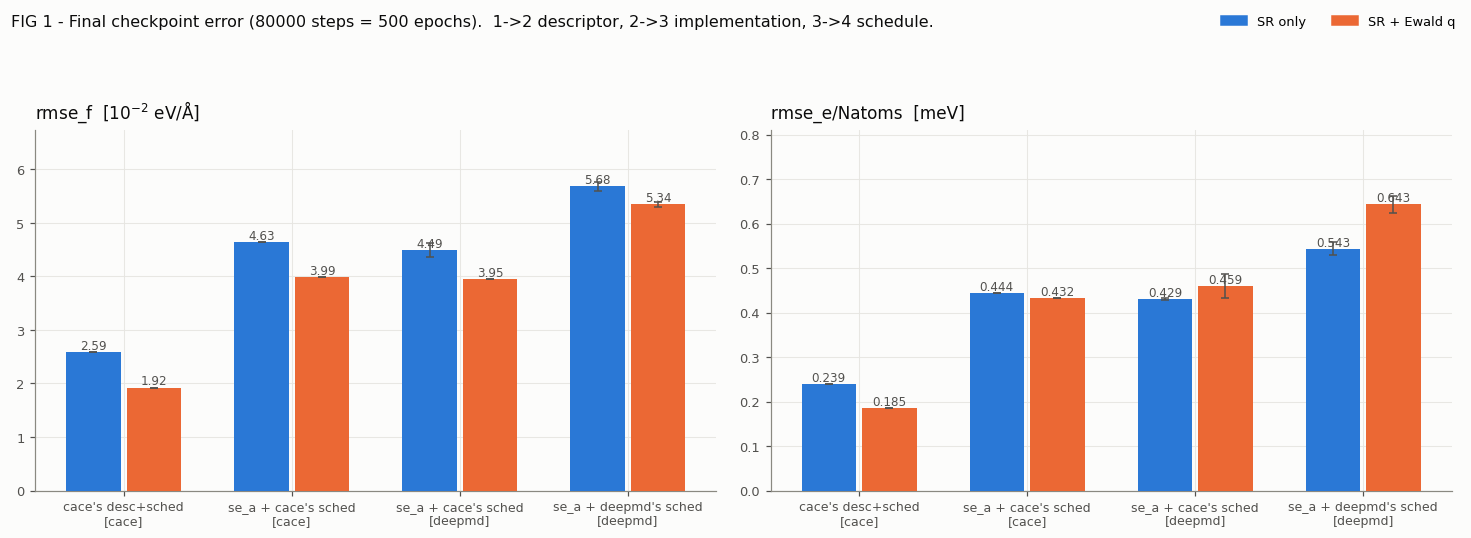

the numbers behind FIG 1:

  force  [1e-2 eV/A]  at the final checkpoint
    cace's desc+sched [cace]               SR       2.5881 +/- 0.0000
    cace's desc+sched [cace]               SR+LR    1.9216 +/- 0.0000
    se_a + cace's sched [cace]             SR       4.6343 +/- 0.0000
    se_a + cace's sched [cace]             SR+LR    3.9860 +/- 0.0000
    se_a + cace's sched [deepmd]           SR       4.4927 +/- 0.1270   replicates 4.3658, 4.6197
    se_a + cace's sched [deepmd]           SR+LR    3.9506 +/- 0.0015   replicates 3.9491, 3.9521
    se_a + deepmd's sched [deepmd]         SR       5.6825 +/- 0.0802   replicates 5.6023, 5.7627
    se_a + deepmd's sched [deepmd]         SR+LR    5.3439 +/- 0.0481   replicates 5.2957, 5.3920

  energy  [meV]  at the final checkpoint
    cace's desc+sched [cace]               SR       0.2385 +/- 0.0000
    cace's desc+sched [cace]               SR+LR    0.1852 +/- 0.0000
    se_a + cace's sched [cace]             SR       0.4437 +/- 0.0000
   

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.9))
x = np.arange(len(CONFIGS))
W = 0.36

for ax, chan, scale, lab in ((axes[0], 'force', 1e2, 'rmse_f  [$10^{-2}$ eV/Å]'),
                             (axes[1], 'energy', 1e3, 'rmse_e/Natoms  [meV]')):
    for k, topo in enumerate(('sr', 'lr')):
        means, errs = [], []
        for c in CONFIGS:
            m, e, _ = group_errors(c[topo], chan)
            means.append(m * scale)
            errs.append(e * scale)
        pos = x + (k - 0.5) * W
        ax.bar(pos, means, width=W * 0.9, color=HUE[topo], zorder=3,
               yerr=errs, error_kw=dict(ecolor=INK2, lw=1.0, capsize=2.5, zorder=4))
        for p, m in zip(pos, means):
            ax.text(p, m, f'{m:.3g}', ha='center', va='bottom', fontsize=7.8, color=INK2)
    ax.set_xticks(x)
    ax.set_xticklabels([c['short'] for c in CONFIGS], fontsize=8.2)
    ax.set_ylim(0, max(means + errs) * 1.26)
    tidy_grid(ax, lab)

fig.legend(handles=[Patch(color=HUE['sr'], label='SR only'),
                    Patch(color=HUE['lr'], label='SR + Ewald q')],
           loc='upper right', bbox_to_anchor=(0.995, 1.0), ncol=2)
fig.suptitle('FIG 1 - Final checkpoint error (80000 steps = 500 epochs).  '
             '1->2 descriptor, 2->3 implementation, 3->4 schedule.',
             x=0.007, ha='left', fontsize=10.5, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

print('the numbers behind FIG 1:')
for chan, scale, unit in (('force', 1e2, '1e-2 eV/A'), ('energy', 1e3, 'meV')):
    print(f'\n  {chan}  [{unit}]  at the final checkpoint')
    for c in CONFIGS:
        for topo, name in (('sr', 'SR'), ('lr', 'SR+LR')):
            m, e, v = group_errors(c[topo], chan)
            rng = (f'   replicates {", ".join(f"{q*scale:.4f}" for q in v)}'
                   if len(v) > 1 else '')
            print(f'    {c["short"].replace(chr(10), " "):38s} {name:6s} '
                  f'{m*scale:8.4f} +/- {e*scale:.4f}{rng}')

## FIG 2 - What each knob is worth

Each row moves one knob and nothing else, so the bar length is that knob's price. The hue is
the topology of the arm that gains, matching FIG 1. Rows are grouped by which knob they move.
The long-range group repeats the same question in every cell of the design, because a term
whose worth interacts with the descriptor or the schedule cannot be priced by one ablation.

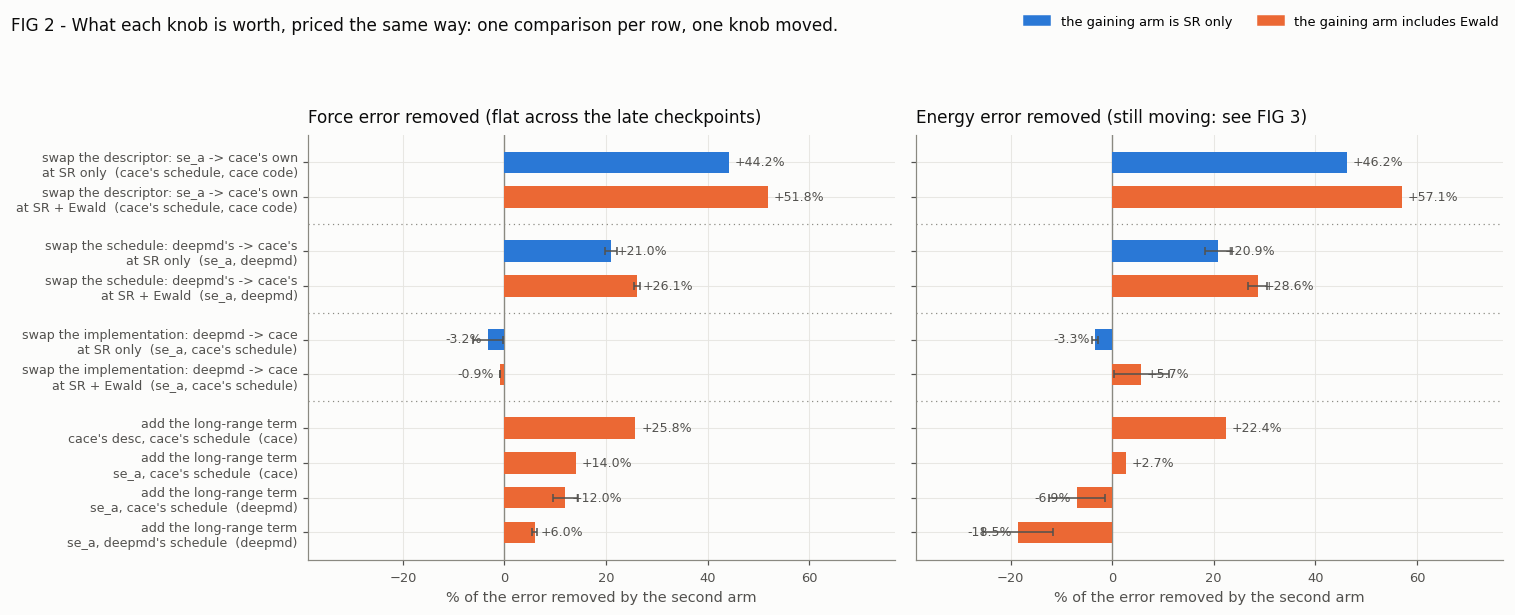

FIG 2's numbers, spelled out (rmse before -> after, then what the second arm removes):

  force
    cace-sea-sr                  4.634299e-02  ->  cace-sr                      2.588108e-02   +44.15%
    cace-sea-lr                  3.985954e-02  ->  cace-lr                      1.921636e-02   +51.79%
    deepmd_sA                    5.602303e-02  ->  deepmd-cace-sched_sA         4.365775e-02   +22.07%
    deepmd_sB                    5.762681e-02  ->  deepmd-cace-sched_sB         4.619705e-02   +19.83%
    deepmd-les_sA                5.295727e-02  ->  deepmd-les-cace-sched_sA     3.949124e-02   +25.43%
    deepmd-les_sB                5.391993e-02  ->  deepmd-les-cace-sched_sB     3.952074e-02   +26.70%
    deepmd-cace-sched_sA         4.365775e-02  ->  cace-sea-sr                  4.634299e-02    -6.15%
    deepmd-cace-sched_sB         4.619705e-02  ->  cace-sea-sr                  4.634299e-02    -0.32%
    deepmd-les-cace-sched_sA     3.949124e-02  ->  cace-sea-lr                  

In [4]:
# Label direction is always "first arm -> second arm", and the bar is what the SECOND arm
# removes, so a positive bar means the swap named on the left is worth that much.
ROWS = [
    ('descriptor', "swap the descriptor: se_a -> cace's own\nat SR only  (cace's schedule, cace code)",
     [('cace-sea-sr', 'cace-sr')]),
    ('descriptor', "swap the descriptor: se_a -> cace's own\nat SR + Ewald  (cace's schedule, cace code)",
     [('cace-sea-lr', 'cace-lr')]),
    ('schedule', "swap the schedule: deepmd's -> cace's\nat SR only  (se_a, deepmd)",
     [('deepmd_sA', 'deepmd-cace-sched_sA'), ('deepmd_sB', 'deepmd-cace-sched_sB')]),
    ('schedule', "swap the schedule: deepmd's -> cace's\nat SR + Ewald  (se_a, deepmd)",
     [('deepmd-les_sA', 'deepmd-les-cace-sched_sA'),
      ('deepmd-les_sB', 'deepmd-les-cace-sched_sB')]),
    ('implementation', "swap the implementation: deepmd -> cace\nat SR only  (se_a, cace's schedule)",
     [('deepmd-cace-sched_sA', 'cace-sea-sr'), ('deepmd-cace-sched_sB', 'cace-sea-sr')]),
    ('implementation', "swap the implementation: deepmd -> cace\nat SR + Ewald  (se_a, cace's schedule)",
     [('deepmd-les-cace-sched_sA', 'cace-sea-lr'),
      ('deepmd-les-cace-sched_sB', 'cace-sea-lr')]),
    ('long-range', "add the long-range term\ncace's desc, cace's schedule  (cace)",
     [('cace-sr', 'cace-lr')]),
    ('long-range', "add the long-range term\nse_a, cace's schedule  (cace)",
     [('cace-sea-sr', 'cace-sea-lr')]),
    ('long-range', "add the long-range term\nse_a, cace's schedule  (deepmd)",
     [('deepmd-cace-sched_sA', 'deepmd-les-cace-sched_sA'),
      ('deepmd-cace-sched_sB', 'deepmd-les-cace-sched_sB')]),
    ('long-range', "add the long-range term\nse_a, deepmd's schedule  (deepmd)",
     [('deepmd_sA', 'deepmd-les_sA'), ('deepmd_sB', 'deepmd-les_sB')]),
]

V = {(chan, lab): paired_leverage([p[0] for p in pairs_ab], [p[1] for p in pairs_ab], chan)
     for chan in ('force', 'energy') for _, lab, pairs_ab in ROWS}
lo = min(v - e for v, e, _ in V.values())
hi = max(v + e for v, e, _ in V.values())
span = hi - lo
# one x-axis for both panels, so a lever can be compared by bar length across panels too
XLIM = (lo - 0.16 * span, hi + 0.24 * span)

# Row positions, top down, with an extra gap where one knob's group ends. Derived from ROWS
# so appending a row needs no new numbers.
SEC_GAP = 0.55
Y, y, prev = [], 0.0, None
for sec, lab, _ in ROWS:
    if prev is not None and sec != prev:
        y -= SEC_GAP
    Y.append(y)
    y -= 1.0
    prev = sec

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.6), sharey=True, sharex=True)
for ax, chan, title in (
        (axes[0], 'force', 'Force error removed (flat across the late checkpoints)'),
        (axes[1], 'energy', 'Energy error removed (still moving: see FIG 3)')):
    for yy, (sec, lab, pairs_ab) in zip(Y, ROWS):
        v, e, _ = V[(chan, lab)]
        gains = 'lr' if ('-lr' in pairs_ab[0][1] or 'les' in pairs_ab[0][1]) else 'sr'
        ax.barh(yy, v, height=0.62, color=HUE[gains], zorder=3,
                xerr=(e if e else None),
                error_kw=dict(ecolor=INK2, lw=1.0, capsize=2.5, zorder=4))
        ax.text(v + np.sign(v if v else 1) * 0.014 * span, yy, f'{v:+.1f}%',
                va='center', ha='left' if v >= 0 else 'right', fontsize=8.2, color=INK2)
    ax.axvline(0.0, color=INK3, lw=0.9, zorder=2)
    for i in range(1, len(ROWS)):
        if ROWS[i][0] != ROWS[i - 1][0]:
            ax.axhline((Y[i - 1] + Y[i]) / 2, color=INK3, lw=0.8, ls=(0, (1, 3)), zorder=1)
    ax.set_xlim(*XLIM)
    ax.set_xticks([t for t in range(-40, 81, 20) if XLIM[0] <= t <= XLIM[1]])
    tidy_grid(ax, title, '% of the error removed by the second arm')
axes[0].set_yticks(Y)
axes[0].set_yticklabels([lab for _, lab, _ in ROWS], fontsize=8.3)
axes[0].set_ylim(min(Y) - 0.8, max(Y) + 0.8)
fig.legend(handles=[Patch(color=HUE['sr'], label='the gaining arm is SR only'),
                    Patch(color=HUE['lr'], label='the gaining arm includes Ewald')],
           loc='upper right', bbox_to_anchor=(0.995, 1.0), ncol=2)
fig.suptitle('FIG 2 - What each knob is worth, priced the same way: one comparison per row, '
             'one knob moved.',
             x=0.007, ha='left', fontsize=11, color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

print("FIG 2's numbers, spelled out (rmse before -> after, then what the second arm removes):")
for chan, i in (('force', 0), ('energy', 1)):
    print(f'\n  {chan}')
    for sec, lab, pairs_ab in ROWS:
        for a, b in pairs_ab:
            ea, eb = final_errors(a)[i], final_errors(b)[i]
            print(f'    {a:28s} {ea:.6e}  ->  {b:28s} {eb:.6e}   {100 * (1 - eb / ea):+6.2f}%')

## FIG 3 - Error against training progress

The final checkpoint is one number per arm, which is only fair if the metric has settled. This
panel is the check: the x-axis is steps, so cace's phase checkpoints (epochs 200 to 500) and
deepmd's checkpoints land on one axis. The deepmd arms on cace's schedule were scored every
3,200 steps, the other deepmd arms every 10,000, and cace at its four phase ends.

Force is flat across the late checkpoints for every arm. Energy is not, and that is the reason
every claim here is about force: a schedule that stopped before the energy settled would let a
schedule effect be read off what is really a stopping-time effect.

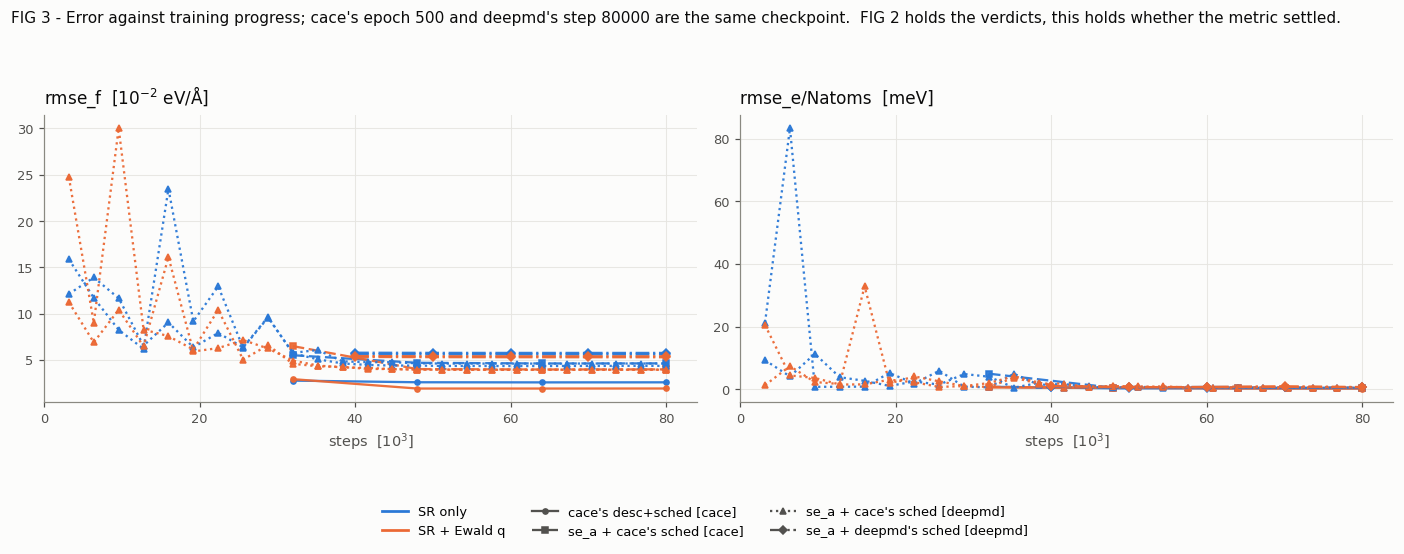

movement over each arm's own late window (last 20% of its steps), as a % of its own mean:
  cace-sr                        SR      force   0.2%   energy   0.4%   (2 pts)
  cace-lr                        SR+LR   force   0.3%   energy  11.8%   (2 pts)
  cace-sea-sr                    SR      force   0.2%   energy   1.4%   (2 pts)
  cace-sea-lr                    SR+LR   force   0.3%   energy   7.0%   (2 pts)
  deepmd-cace-sched_sA           SR      force   0.5%   energy  12.0%   (6 pts)
  deepmd-cace-sched_sB           SR      force   0.2%   energy   1.8%   (6 pts)
  deepmd-les-cace-sched_sA       SR+LR   force   0.3%   energy  18.5%   (6 pts)
  deepmd-les-cace-sched_sB       SR+LR   force   0.3%   energy   5.7%   (6 pts)
  deepmd_sA                      SR      force   0.0%   energy   8.7%   (2 pts)
  deepmd_sB                      SR      force   0.0%   energy   1.3%   (2 pts)
  deepmd-les_sA                  SR+LR   force   0.0%   energy  34.9%   (2 pts)


  deepmd-les_sB                  SR+LR   force   0.0%   energy  10.9%   (2 pts)


In [5]:
# one long frame, with cace's epoch axis converted onto the shared step axis
prog = pd.concat(
    [sw[['arm', 'step', 'rmse_f', 'rmse_e_peratom']],
     scored.assign(step=scored['epoch'] * STEPS_PER_EPOCH)[
         ['arm', 'step', 'rmse_f', 'rmse_e_peratom']]],
    ignore_index=True)

LS = {0: '-', 1: (0, (5, 2)), 2: (0, (1, 1.6)), 3: (0, (6, 1.6, 1, 1.6))}
MK = {0: 'o', 1: 's', 2: '^', 3: 'D'}

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9))
for ax, chan, scale, lab in ((axes[0], 'rmse_f', 1e2, 'rmse_f  [$10^{-2}$ eV/Å]'),
                             (axes[1], 'rmse_e_peratom', 1e3, 'rmse_e/Natoms  [meV]')):
    for ci, c in enumerate(CONFIGS):
        for topo in ('sr', 'lr'):
            for a in c[topo]:
                d = prog[prog['arm'] == a].sort_values('step')
                if not len(d):
                    continue
                ax.plot(d['step'] / 1000.0, d[chan] * scale, color=HUE[topo], ls=LS[ci],
                        marker=MK[ci], ms=3.4, lw=1.5, alpha=0.95, zorder=3)
    ax.set_xlim(0, 84)
    ax.set_xticks([0, 20, 40, 60, 80])
    tidy_grid(ax, lab, 'steps  [$10^3$]')

handles = [plt.Line2D([], [], color=HUE[t], lw=1.8, label=f'{n}')
           for t, n in (('sr', 'SR only'), ('lr', 'SR + Ewald q'))] + \
          [plt.Line2D([], [], color=INK2, ls=LS[i], marker=MK[i], ms=3.4, lw=1.5,
                      label=c['short'].replace('\n', ' '))
           for i, c in enumerate(CONFIGS)]
fig.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)
fig.suptitle("FIG 3 - Error against training progress; cace's epoch 500 and deepmd's step "
             '80000 are the same checkpoint.  FIG 2 holds the verdicts, this holds whether '
             'the metric settled.',
             x=0.007, ha='left', fontsize=10, color=INK)
fig.tight_layout(rect=(0, 0.13, 1, 0.93))
plt.show()

print("movement over each arm's own late window (last 20% of its steps), as a % of its own mean:")
for c in CONFIGS:
    for topo, name in (('sr', 'SR'), ('lr', 'SR+LR')):
        for a in c[topo]:
            d = prog[prog['arm'] == a].sort_values('step')
            late = d[d['step'] >= d['step'].max() * 0.8]
            if len(late) < 2:
                continue
            df = 100 * (np.ptp(late['rmse_f']) / late['rmse_f'].mean())
            de = 100 * (np.ptp(late['rmse_e_peratom']) / late['rmse_e_peratom'].mean())
            print(f'  {a:30s} {name:6s}  force {df:5.1f}%   energy {de:5.1f}%   '
                  f'({len(late)} pts)')

## The numbers, in one place

Everything the figures draw, at the final checkpoint, plus each arm's checkpoint list so the
progress axis can be re-derived by hand.

In [6]:
print('final checkpoint per arm (force in 1e-2 eV/A, energy in meV):')
rows = []
for c in CONFIGS:
    for topo, name in (('sr', 'SR'), ('lr', 'SR+LR')):
        mf, _e, _v = group_errors(c[topo], 'force')
        mev, _e2, _v2 = group_errors(c[topo], 'energy')
        rows.append(dict(cell=c['short'].replace('\n', ' '), topology=name,
                         rmse_f_1e2=round(mf * 1e2, 4), rmse_e_meV=round(mev * 1e3, 4),
                         arms=','.join(c[topo])))
print(pd.DataFrame(rows).to_string(index=False))

print('\ncheckpoints scored per arm:')
for a in ALL_ARMS:
    d = scored if a in set(scored['arm']) else sw
    key = 'epoch' if a in set(scored['arm']) else 'step'
    v = sorted(int(k) if float(k).is_integer() else float(k)
               for k in d[d['arm'] == a][key].unique())
    print(f'  {a:30s} {key:5s} {v}')

final checkpoint per arm (force in 1e-2 eV/A, energy in meV):
                          cell topology  rmse_f_1e2  rmse_e_meV                                              arms
      cace's desc+sched [cace]       SR      2.5881      0.2385                                           cace-sr
      cace's desc+sched [cace]    SR+LR      1.9216      0.1852                                           cace-lr
    se_a + cace's sched [cace]       SR      4.6343      0.4437                                       cace-sea-sr
    se_a + cace's sched [cace]    SR+LR      3.9860      0.4316                                       cace-sea-lr
  se_a + cace's sched [deepmd]       SR      4.4927      0.4295         deepmd-cace-sched_sA,deepmd-cace-sched_sB
  se_a + cace's sched [deepmd]    SR+LR      3.9506      0.4592 deepmd-les-cace-sched_sA,deepmd-les-cace-sched_sB
se_a + deepmd's sched [deepmd]       SR      5.6825      0.5434                               deepmd_sA,deepmd_sB
se_a + deepmd's sched [dee